In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import cv2


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load your model architecture
num_classes = 79  # adjust if fewer
model = models.resnet50(pretrained=True)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)
model.load_state_dict(torch.load("torch_checkpoints/best_model.pth", map_location=device))
model.to(device)
model.eval()


c:\Users\Harsh\.conda\envs\new_yoga\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Harsh\.conda\envs\new_yoga\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
data_dir = "../data/images"  # path to dataset
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

dataset = ImageFolder(data_dir, transform=transform)
class_names = dataset.classes
print("Classes:", class_names)

loader = DataLoader(dataset, batch_size=1, shuffle=False)


Classes: ['Akarna_Dhanurasana', 'Bharadvajas_Twist_pose_or_Bharadvajasana_I_', 'Boat_Pose_or_Paripurna_Navasana_', 'Bound_Angle_Pose_or_Baddha_Konasana_', 'Bow_Pose_or_Dhanurasana_', 'Bridge_Pose_or_Setu_Bandha_Sarvangasana_', 'Camel_Pose_or_Ustrasana_', 'Cat_Cow_Pose_or_Marjaryasana_', 'Chair_Pose_or_Utkatasana_', 'Child_Pose_or_Balasana_', 'Cobra_Pose_or_Bhujangasana_', 'Cockerel_Pose', 'Corpse_Pose_or_Savasana_', 'Cow_Face_Pose_or_Gomukhasana_', 'Crane_(Crow)_Pose_or_Bakasana_', 'Dolphin_Pose_or_Ardha_Pincha_Mayurasana_', 'Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_', 'Eagle_Pose_or_Garudasana_', 'Eight-Angle_Pose_or_Astavakrasana_', 'Extended_Puppy_Pose_or_Uttana_Shishosana_', 'Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_', 'Extended_Revolved_Triangle_Pose_or_Utthita_Trikonasana_', 'Feathered_Peacock_Pose_or_Pincha_Mayurasana_', 'Firefly_Pose_or_Tittibhasana_', 'Fish_Pose_or_Matsyasana_', 'Four-Limbed_Staff_Pose_or_Chaturanga_Dandasana_', 'Frog_Pose_or_Bhekasa

In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, target_class=None):
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        loss = output[0, target_class]
        self.model.zero_grad()
        loss.backward()

        gradients = self.gradients.detach().cpu().numpy()[0]
        activations = self.activations.detach().cpu().numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam


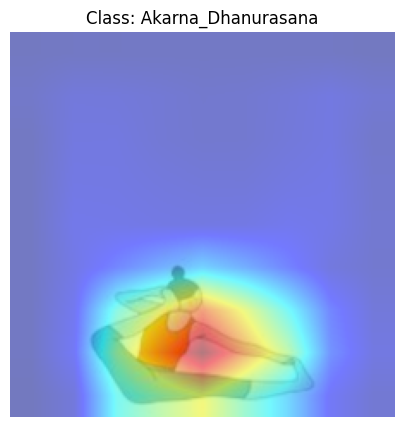

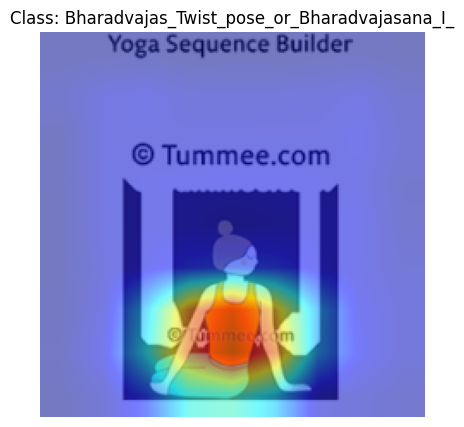

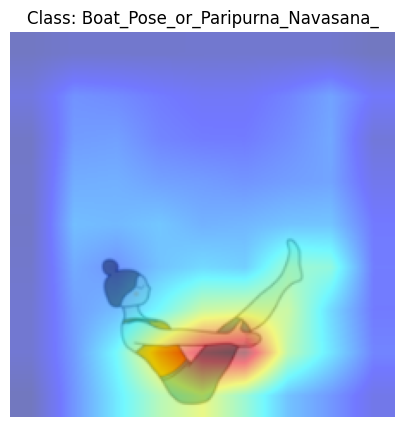

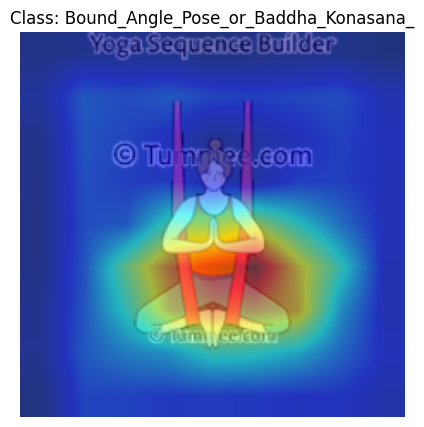

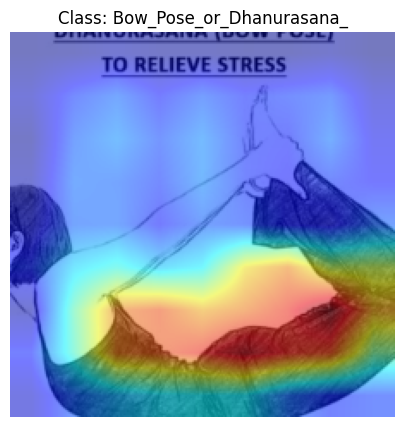

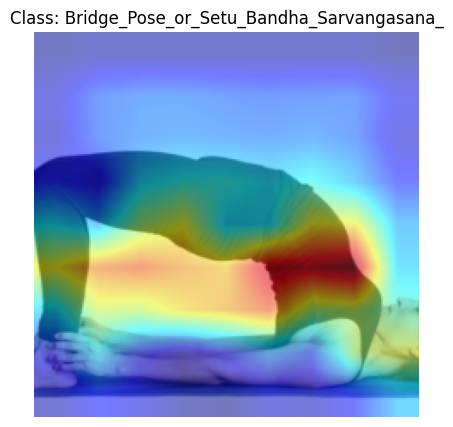

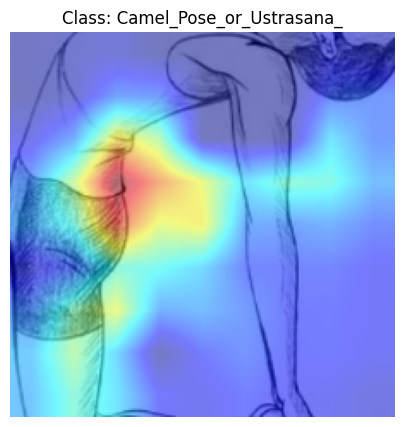

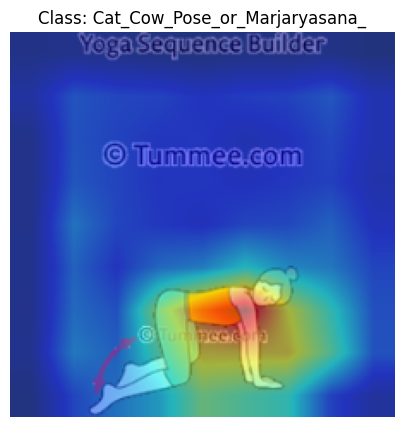

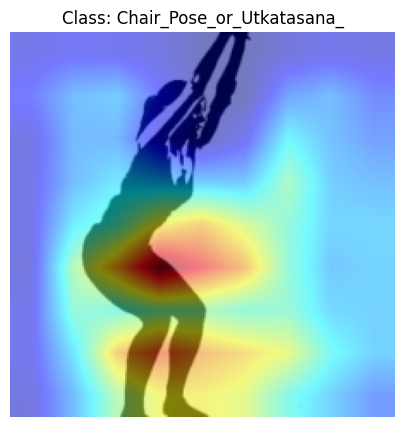

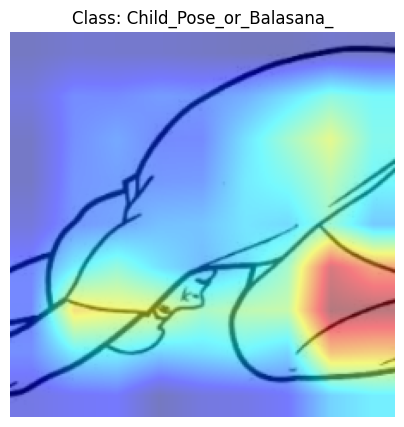

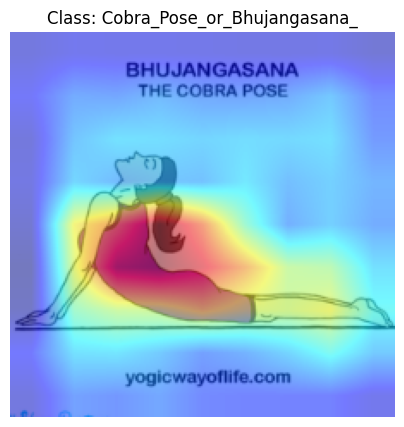

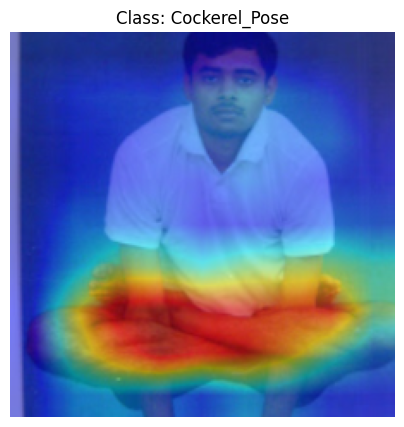

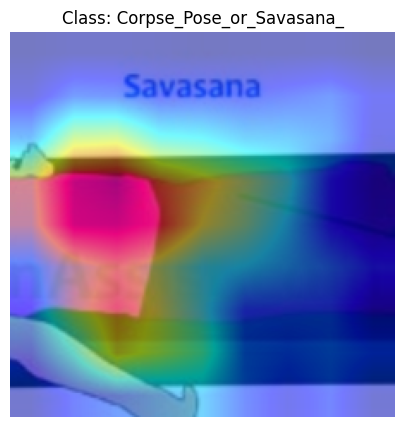

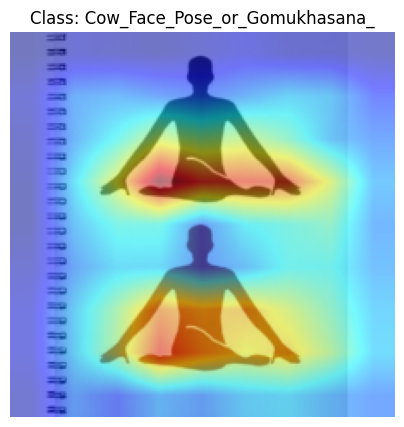

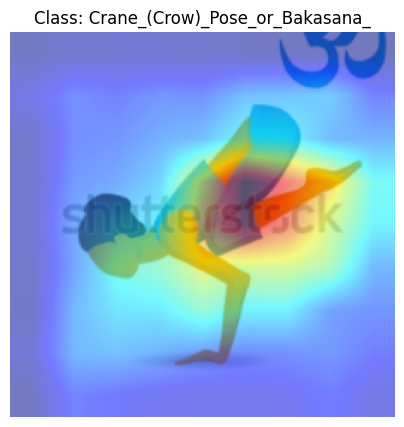

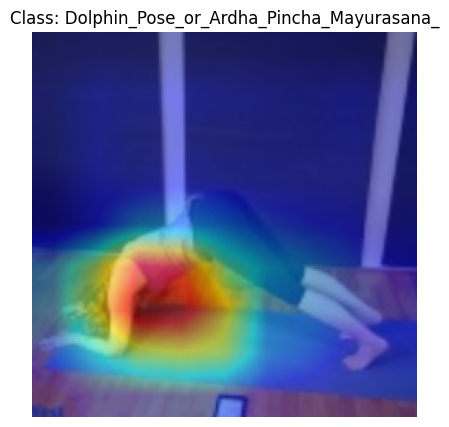

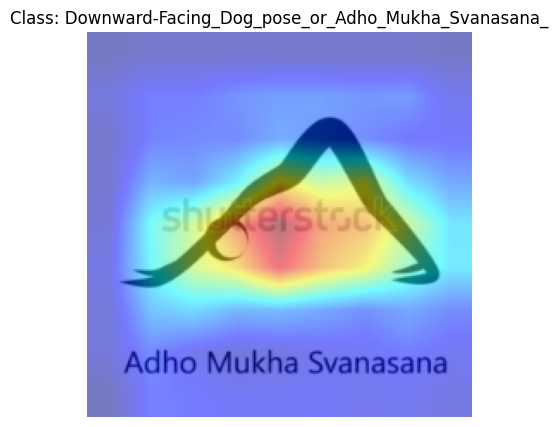

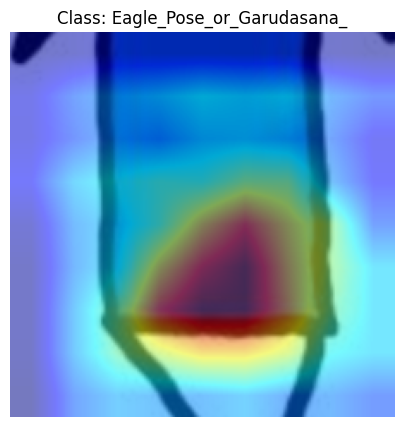

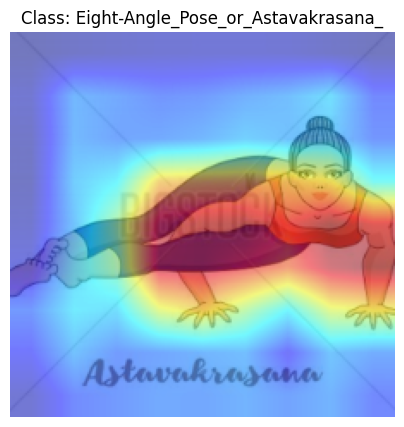

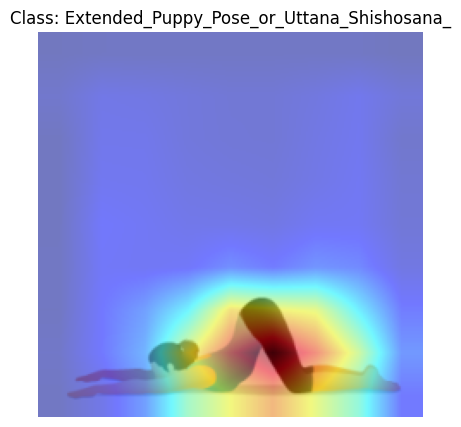

In [9]:
gradcam = GradCAM(model, model.layer4[-1])  # last conv block

def show_cam_on_image(img_tensor, cam, class_name):
    # Convert tensor to numpy (C,H,W → H,W,C)
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    # Resize img to 224x224 (same as cam)
    img = cv2.resize(img, (224, 224))

    # Apply heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = np.float32(heatmap) / 255 + img
    overlay = overlay / overlay.max()

    # Show
    plt.figure(figsize=(5,5))
    plt.title(f"Class: {class_name}")
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()


# Pick 1 sample per class
seen_classes = set()
for inputs, labels in loader:
    class_name = class_names[labels.item()]
    if class_name not in seen_classes:
        inputs = inputs.to(device)
        cam = gradcam.generate(inputs)
        show_cam_on_image(inputs[0], cam, class_name)
        seen_classes.add(class_name)
    if len(seen_classes) >= 20:  # show first 10 classes for summary
        break
